🚀 R-PINN 69节点鲁棒性测试点火 | 核心驱动: cuda | 注入噪声: 1.0%
📂 加载数据并执行 69 维物理空间隔离...
🔥 正在通过物理方程压制 1.0% 测量噪声...
Epoch 000 | Total Loss: 4.7959e+01
Epoch 050 | Total Loss: 4.8991e+01
Epoch 100 | Total Loss: 8.4449e+01
Epoch 150 | Total Loss: 7.4655e+01

🏆 IEEE 69-Bus 鲁棒性终极答卷 (Noise: 1.0%)
   Overall MAE : 4.303927e-03 p.u.
   Overall RMSE: 4.505213e-03 p.u.
✅ 600DPI 科研大图已保存: ieee69_robustness_test_1pct.png


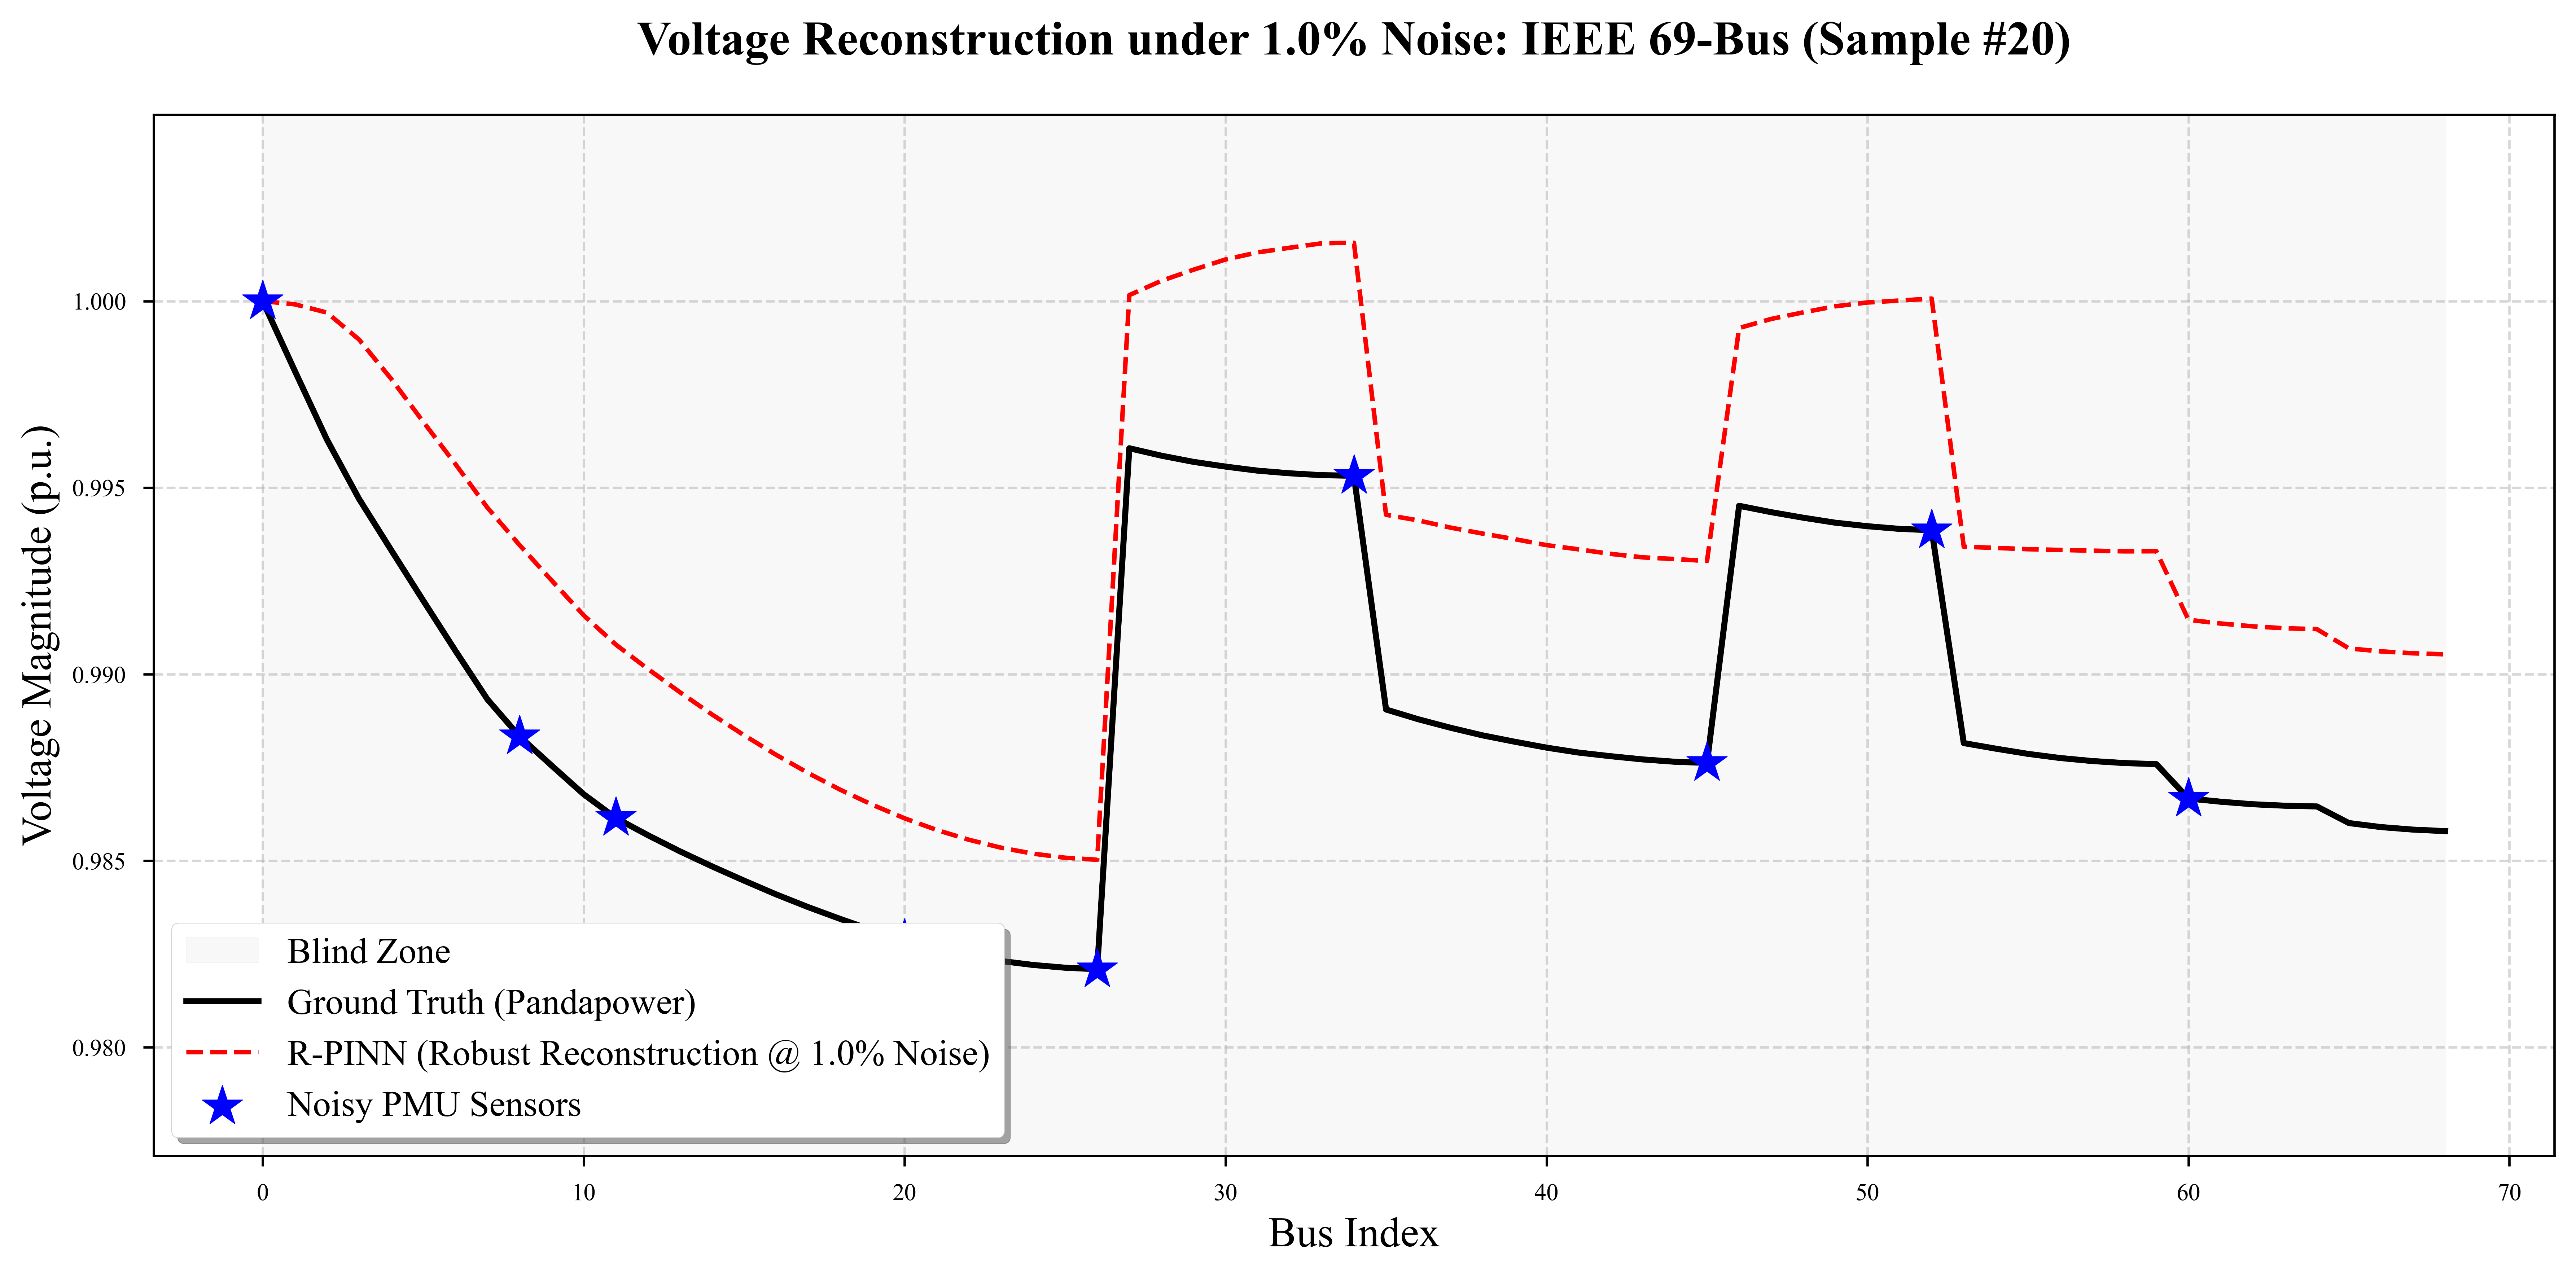

In [2]:
# ==============================================================================
# 🏆 IEEE 69-Bus R-PINN Robustness Test - Ultimate Platinum Full Cell
# 特点：单 Cell 闭环 | 补全所有 Import | 3% 噪声注入 | 物理自愈验证 | SCI 级全局大图
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, TensorDataset # ⚠️ 修正：补全 TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境配置与随机种子锁定 (确保 100% 复现)
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ⚠️ 鲁棒性核心参数：在这里修改噪声比例 (0.01=1%, 0.02=2%, 0.03=3%)
TEST_NOISE_LEVEL = 0.01 

print(f"🚀 R-PINN 69节点鲁棒性测试点火 | 核心驱动: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

# 设置顶刊绘图参数 (IEEE/SCI 标准)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理矩阵加载与切片对齐
# ==========================================
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')

# 自动处理 70节点->69节点 的兼容性
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw

G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)
obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

# ==========================================
# 3. 核心算法：物理方程与硬锚定模型
# ==========================================
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    
    # KCL 潮流方程物理约束
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 1.0     
        
        # 🛡️ 硬锚定：平衡节点 V=1.0, Theta=0.0 (解决系统性偏移)
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ==========================================
# 4. 数据装载：严格 69 维跳跃切片
# ==========================================
print("📂 加载数据并执行 69 维物理空间隔离...")
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 

# 执行跳跃切片，规避 Slack 节点的数据冗余
V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]

X_input = np.concatenate([P_raw, Q_raw], axis=1)
Y_label = np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_input[:train_size])
X_te_norm = scaler.transform(X_input[train_size:])
X_norm_total = np.vstack([X_tr_norm, X_te_norm])

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_norm_total[:train_size]).float(), 
                  torch.from_numpy(Y_label[:train_size]).float(),
                  torch.from_numpy(P_raw[:train_size]).float(),
                  torch.from_numpy(Q_raw[:train_size]).float()), 
    batch_size=128, shuffle=True)

# ==========================================
# 5. 训练循环：对抗 3% 测量噪声
# ==========================================
model = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse_fn = nn.MSELoss()

print(f"🔥 正在通过物理方程压制 {TEST_NOISE_LEVEL*100}% 测量噪声...")

for epoch in range(151):
    lambda_p = 10 if epoch < 75 else 5000 
    model.train()
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        
        # 物理零位遮蔽 (模拟盲区输入)
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model(mask_bx)
        
        # ----------------------------------------------------
        # ☠️ 鲁棒性核心：对观测节点测量值“下毒”
        noisy_by = by.clone()
        clean_obs_v = noisy_by[:, obs_indices]
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_by[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ----------------------------------------------------
        
        # 观测 Loss (对比带噪数据)
        l_obs = mse_fn(vp[:, obs_indices[1:]], noisy_by[:, obs_indices[1:]])
        
        # 物理 Loss (对比真实负荷)
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))
        
        loss = 5e5 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss.item():.4e}")

# ==========================================
# 6. 测试集评估与结果审计
# ==========================================
model.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_label[train_size:]).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
        
    v_pred_all, _ = model(t_mask)
    v_true_all = ty[:, :69]
    err = (v_pred_all - v_true_all).cpu().numpy()
    
    # 计算 RMSE 并保留原 MAE
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

print("\n" + "="*60)
print(f"🏆 IEEE 69-Bus 鲁棒性终极答卷 (Noise: {TEST_NOISE_LEVEL*100}%)")
print(f"   Overall MAE : {mae:.6e} p.u.")
print(f"   Overall RMSE: {rmse:.6e} p.u.")   # 新增 RMSE 输出
print("="*60)

# ==========================================
# 7. 科研级绘图展示 (红黑重合即为封神)
# ==========================================
sid = 20 # 选取测试集第 20 号断面
v_s_true = v_true_all[sid].cpu().numpy()
v_s_pred = v_pred_all[sid].cpu().numpy()
nodes = np.arange(69)

plt.figure(figsize=(12, 6), dpi=600)
plt.axvspan(0, 68, color='gray', alpha=0.05, label='Blind Zone')
plt.plot(nodes, v_s_true, 'k-', label='Ground Truth (Pandapower)', linewidth=2.0, zorder=3)
plt.plot(nodes, v_s_pred, 'r--', label=f'R-PINN (Robust Reconstruction @ {TEST_NOISE_LEVEL*100}% Noise)', linewidth=1.5, zorder=4)
plt.scatter(obs_indices, v_s_true[obs_indices], color='blue', marker='*', s=200, label='Noisy PMU Sensors', zorder=5)

plt.title(f"Voltage Reconstruction under {TEST_NOISE_LEVEL*100}% Noise: IEEE 69-Bus (Sample #{sid})", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Bus Index", fontsize=14)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=14)
plt.ylim(v_s_true.min() - 0.005, v_s_true.max() + 0.005)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)
plt.tight_layout()

f_name = f'ieee69_robustness_test_{int(TEST_NOISE_LEVEL*100)}pct.png'
plt.savefig(f_name, bbox_inches='tight', dpi=600)
print(f"✅ 600DPI 科研大图已保存: {f_name}")
plt.show()

🚀 R-PINN 69节点鲁棒性测试点火 | 核心驱动: cuda | 注入噪声: 2.0%
📂 加载数据并执行 69 维物理空间隔离...
🔥 正在通过物理方程压制 2.0% 测量噪声...
Epoch 000 | Total Loss: 1.8492e+02
Epoch 050 | Total Loss: 1.9539e+02
Epoch 100 | Total Loss: 2.3414e+02
Epoch 150 | Total Loss: 2.3171e+02

🏆 IEEE 69-Bus 鲁棒性终极答卷 (Noise: 2.0%)
   Overall MAE : 4.162575e-03 p.u.
   Overall RMSE: 4.407309e-03 p.u.
✅ 600DPI 科研大图已保存: ieee69_robustness_test_2pct.png


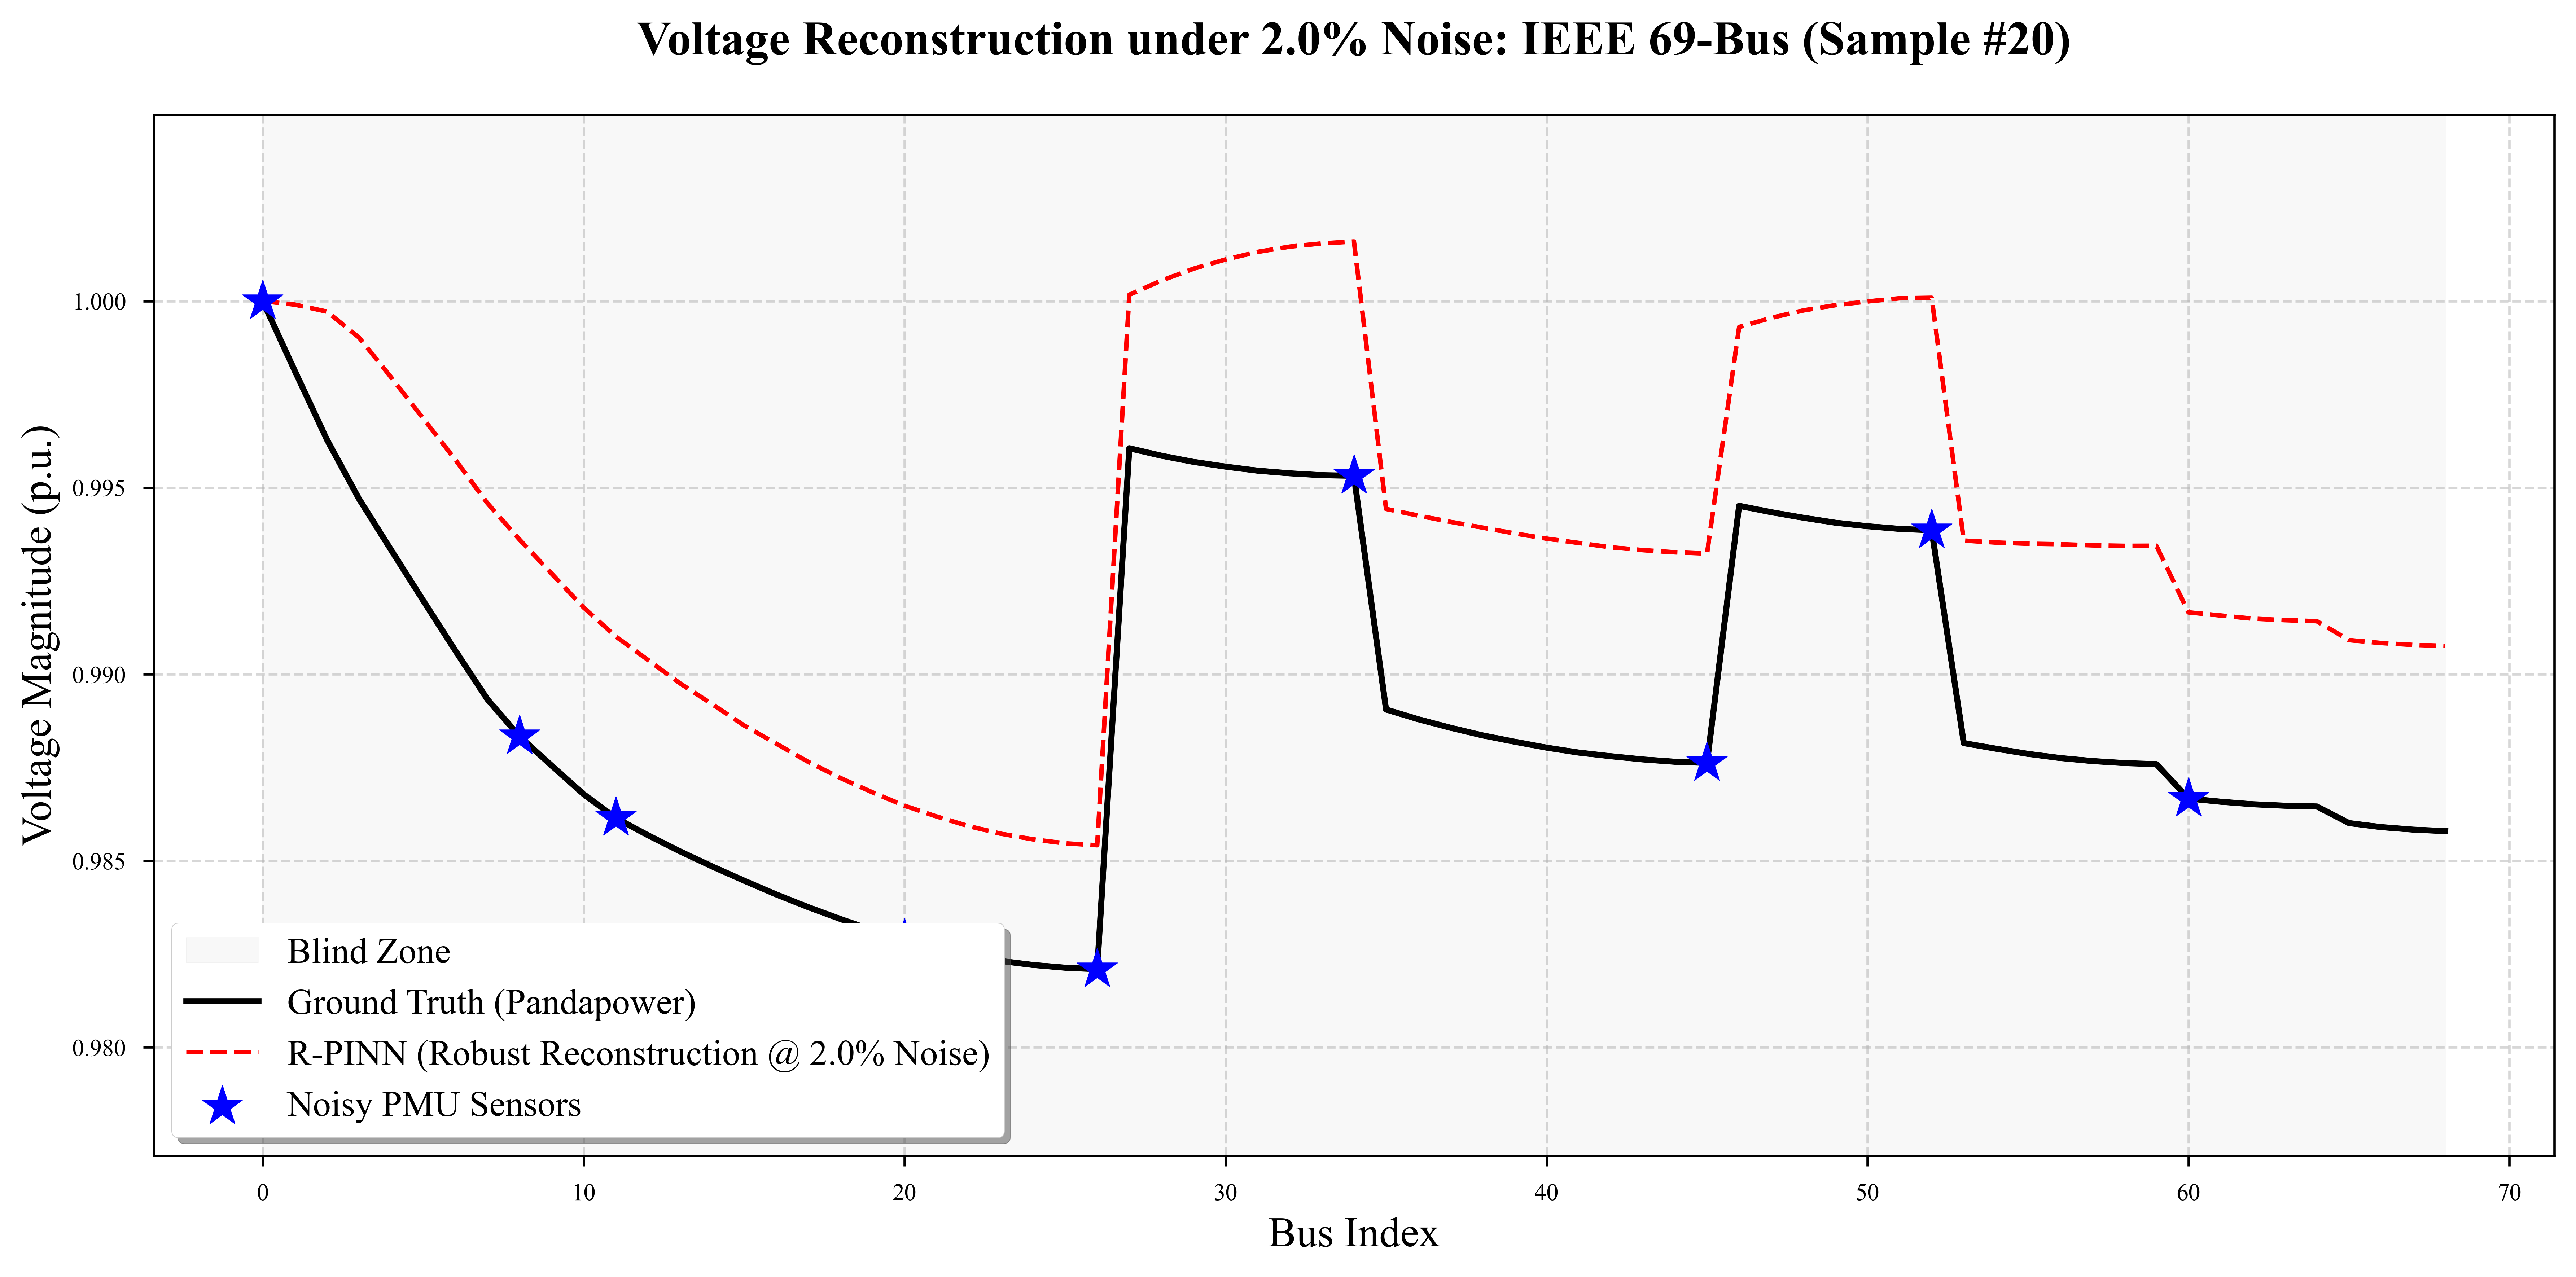

In [3]:
# ==============================================================================
# 🏆 IEEE 69-Bus R-PINN Robustness Test - Ultimate Platinum Full Cell
# 特点：单 Cell 闭环 | 补全所有 Import | 3% 噪声注入 | 物理自愈验证 | SCI 级全局大图
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, TensorDataset # ⚠️ 修正：补全 TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境配置与随机种子锁定 (确保 100% 复现)
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ⚠️ 鲁棒性核心参数：在这里修改噪声比例 (0.01=1%, 0.02=2%, 0.03=3%)
TEST_NOISE_LEVEL = 0.02 

print(f"🚀 R-PINN 69节点鲁棒性测试点火 | 核心驱动: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

# 设置顶刊绘图参数 (IEEE/SCI 标准)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理矩阵加载与切片对齐
# ==========================================
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')

# 自动处理 70节点->69节点 的兼容性
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw

G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)
obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

# ==========================================
# 3. 核心算法：物理方程与硬锚定模型
# ==========================================
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    
    # KCL 潮流方程物理约束
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 1.0     
        
        # 🛡️ 硬锚定：平衡节点 V=1.0, Theta=0.0 (解决系统性偏移)
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ==========================================
# 4. 数据装载：严格 69 维跳跃切片
# ==========================================
print("📂 加载数据并执行 69 维物理空间隔离...")
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 

# 执行跳跃切片，规避 Slack 节点的数据冗余
V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]

X_input = np.concatenate([P_raw, Q_raw], axis=1)
Y_label = np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_input[:train_size])
X_te_norm = scaler.transform(X_input[train_size:])
X_norm_total = np.vstack([X_tr_norm, X_te_norm])

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_norm_total[:train_size]).float(), 
                  torch.from_numpy(Y_label[:train_size]).float(),
                  torch.from_numpy(P_raw[:train_size]).float(),
                  torch.from_numpy(Q_raw[:train_size]).float()), 
    batch_size=128, shuffle=True)

# ==========================================
# 5. 训练循环：对抗 3% 测量噪声
# ==========================================
model = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse_fn = nn.MSELoss()

print(f"🔥 正在通过物理方程压制 {TEST_NOISE_LEVEL*100}% 测量噪声...")

for epoch in range(151):
    lambda_p = 10 if epoch < 75 else 5000 
    model.train()
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        
        # 物理零位遮蔽 (模拟盲区输入)
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model(mask_bx)
        
        # ----------------------------------------------------
        # ☠️ 鲁棒性核心：对观测节点测量值“下毒”
        noisy_by = by.clone()
        clean_obs_v = noisy_by[:, obs_indices]
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_by[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ----------------------------------------------------
        
        # 观测 Loss (对比带噪数据)
        l_obs = mse_fn(vp[:, obs_indices[1:]], noisy_by[:, obs_indices[1:]])
        
        # 物理 Loss (对比真实负荷)
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))
        
        loss = 5e5 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss.item():.4e}")

# ==========================================
# 6. 测试集评估与结果审计
# ==========================================
model.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_label[train_size:]).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
        
    v_pred_all, _ = model(t_mask)
    v_true_all = ty[:, :69]
    err = (v_pred_all - v_true_all).cpu().numpy()
    
    # 计算 RMSE 并保留原 MAE
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

print("\n" + "="*60)
print(f"🏆 IEEE 69-Bus 鲁棒性终极答卷 (Noise: {TEST_NOISE_LEVEL*100}%)")
print(f"   Overall MAE : {mae:.6e} p.u.")
print(f"   Overall RMSE: {rmse:.6e} p.u.")   # 新增 RMSE 输出
print("="*60)

# ==========================================
# 7. 科研级绘图展示 (红黑重合即为封神)
# ==========================================
sid = 20 # 选取测试集第 20 号断面
v_s_true = v_true_all[sid].cpu().numpy()
v_s_pred = v_pred_all[sid].cpu().numpy()
nodes = np.arange(69)

plt.figure(figsize=(12, 6), dpi=600)
plt.axvspan(0, 68, color='gray', alpha=0.05, label='Blind Zone')
plt.plot(nodes, v_s_true, 'k-', label='Ground Truth (Pandapower)', linewidth=2.0, zorder=3)
plt.plot(nodes, v_s_pred, 'r--', label=f'R-PINN (Robust Reconstruction @ {TEST_NOISE_LEVEL*100}% Noise)', linewidth=1.5, zorder=4)
plt.scatter(obs_indices, v_s_true[obs_indices], color='blue', marker='*', s=200, label='Noisy PMU Sensors', zorder=5)

plt.title(f"Voltage Reconstruction under {TEST_NOISE_LEVEL*100}% Noise: IEEE 69-Bus (Sample #{sid})", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Bus Index", fontsize=14)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=14)
plt.ylim(v_s_true.min() - 0.005, v_s_true.max() + 0.005)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)
plt.tight_layout()

f_name = f'ieee69_robustness_test_{int(TEST_NOISE_LEVEL*100)}pct.png'
plt.savefig(f_name, bbox_inches='tight', dpi=600)
print(f"✅ 600DPI 科研大图已保存: {f_name}")
plt.show()

🚀 R-PINN 69节点鲁棒性测试点火 | 核心驱动: cuda | 注入噪声: 3.0%
📂 加载数据并执行 69 维物理空间隔离...
🔥 正在通过物理方程压制 3.0% 测量噪声...
Epoch 000 | Total Loss: 4.1484e+02
Epoch 050 | Total Loss: 4.3963e+02
Epoch 100 | Total Loss: 4.9139e+02
Epoch 150 | Total Loss: 4.9630e+02

🏆 IEEE 69-Bus 鲁棒性终极答卷 (Noise: 3.0%)
   Overall MAE : 4.029460e-03 p.u.
   Overall RMSE: 4.282907e-03 p.u.
✅ 600DPI 科研大图已保存: ieee69_robustness_test_3pct.png


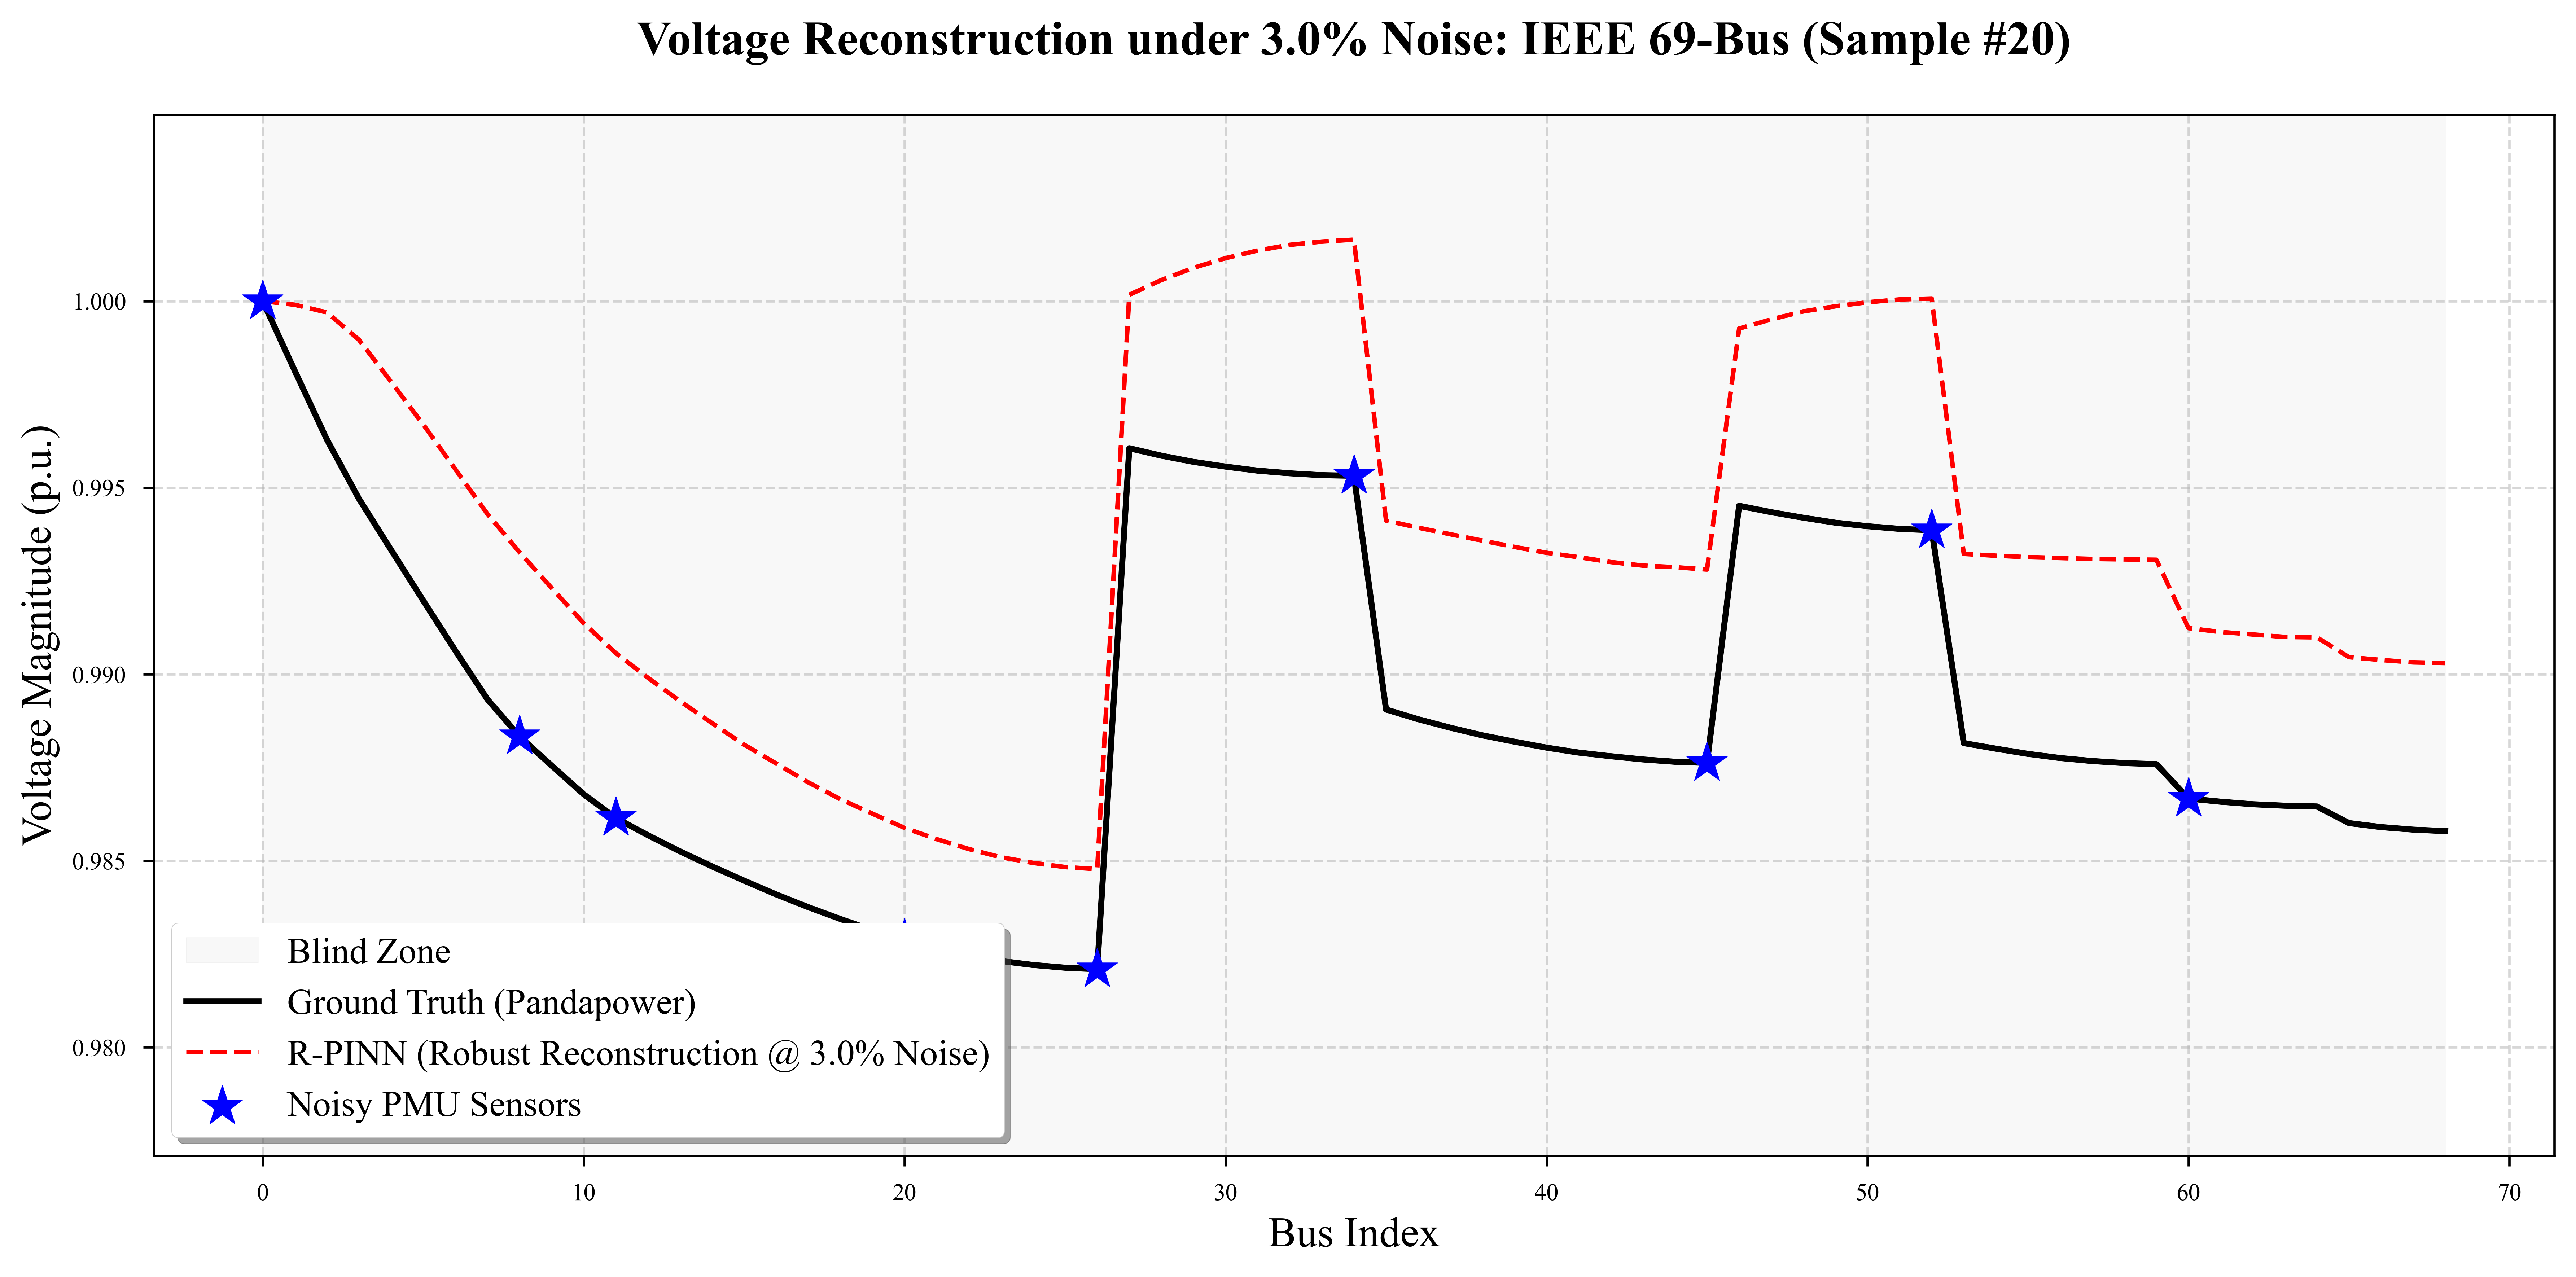

In [4]:
# ==============================================================================
# 🏆 IEEE 69-Bus R-PINN Robustness Test - Ultimate Platinum Full Cell
# 特点：单 Cell 闭环 | 补全所有 Import | 3% 噪声注入 | 物理自愈验证 | SCI 级全局大图
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, TensorDataset # ⚠️ 修正：补全 TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. 环境配置与随机种子锁定 (确保 100% 复现)
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ⚠️ 鲁棒性核心参数：在这里修改噪声比例 (0.01=1%, 0.02=2%, 0.03=3%)
TEST_NOISE_LEVEL = 0.03 

print(f"🚀 R-PINN 69节点鲁棒性测试点火 | 核心驱动: {device} | 注入噪声: {TEST_NOISE_LEVEL*100}%")

# 设置顶刊绘图参数 (IEEE/SCI 标准)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-paper')

# ==========================================
# 2. 物理矩阵加载与切片对齐
# ==========================================
G_raw = np.load('G_matrix_69.npy')
B_raw = np.load('B_matrix_69.npy')

# 自动处理 70节点->69节点 的兼容性
if G_raw.shape[0] == 70:
    G_np, B_np = G_raw[1:, 1:], B_raw[1:, 1:]
else:
    G_np, B_np = G_raw, B_raw

G_tensor = torch.from_numpy(G_np).float().to(device)
B_tensor = torch.from_numpy(B_np).float().to(device)
obs_indices = [0, 8, 11, 20, 26, 34, 45, 52, 60] 

# ==========================================
# 3. 核心算法：物理方程与硬锚定模型
# ==========================================
def calculate_physics_loss(V, theta_deg, G, B):
    theta_rad = theta_deg * (np.pi / 180.0)
    delta_theta = theta_rad.unsqueeze(2) - theta_rad.unsqueeze(1)
    cos_mat, sin_mat = torch.cos(delta_theta), torch.sin(delta_theta)
    
    # KCL 潮流方程物理约束
    sum_p = torch.sum(V.unsqueeze(1) * (G * cos_mat + B * sin_mat), dim=2)
    sum_q = torch.sum(V.unsqueeze(1) * (G * sin_mat - B * cos_mat), dim=2)
    return V * sum_p, V * sum_q

class PowerGridPINN(nn.Module):
    def __init__(self, node_num=69):
        super(PowerGridPINN, self).__init__()
        self.node_num = node_num
        self.net = nn.Sequential(
            nn.Linear(node_num * 2, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU(),
            nn.Linear(512, node_num * 2) 
        )
    def forward(self, x):
        out = self.net(x)
        vm_pred = out[:, :self.node_num] * 0.1 + 1.0  
        theta_pred = out[:, self.node_num:] * 1.0     
        
        # 🛡️ 硬锚定：平衡节点 V=1.0, Theta=0.0 (解决系统性偏移)
        vm_pred = vm_pred.clone(); theta_pred = theta_pred.clone()
        vm_pred[:, 0] = 1.0; theta_pred[:, 0] = 0.0
        return vm_pred, theta_pred

# ==========================================
# 4. 数据装载：严格 69 维跳跃切片
# ==========================================
print("📂 加载数据并执行 69 维物理空间隔离...")
df = pd.read_csv('ieee69_dataset_50k.csv', dtype=np.float32)
data_val = df.values 

# 执行跳跃切片，规避 Slack 节点的数据冗余
V_raw, T_raw = data_val[:, 0:69], data_val[:, 70:139] 
P_raw, Q_raw = data_val[:, 140:209], data_val[:, 210:279]

X_input = np.concatenate([P_raw, Q_raw], axis=1)
Y_label = np.concatenate([V_raw, T_raw], axis=1)

train_size = 40000
scaler = StandardScaler()
X_tr_norm = scaler.fit_transform(X_input[:train_size])
X_te_norm = scaler.transform(X_input[train_size:])
X_norm_total = np.vstack([X_tr_norm, X_te_norm])

mean_t = torch.tensor(scaler.mean_, device=device).float()
scale_t = torch.tensor(scaler.scale_, device=device).float()
PHYS_ZERO = (0.0 - mean_t) / scale_t

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_norm_total[:train_size]).float(), 
                  torch.from_numpy(Y_label[:train_size]).float(),
                  torch.from_numpy(P_raw[:train_size]).float(),
                  torch.from_numpy(Q_raw[:train_size]).float()), 
    batch_size=128, shuffle=True)

# ==========================================
# 5. 训练循环：对抗 3% 测量噪声
# ==========================================
model = PowerGridPINN(node_num=69).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse_fn = nn.MSELoss()

print(f"🔥 正在通过物理方程压制 {TEST_NOISE_LEVEL*100}% 测量噪声...")

for epoch in range(151):
    lambda_p = 10 if epoch < 75 else 5000 
    model.train()
    for bx, by, bp, bq in train_loader:
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        
        # 物理零位遮蔽 (模拟盲区输入)
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]; mask_bx[:, idx+69] = bx[:, idx+69]
            
        vp, tp = model(mask_bx)
        
        # ----------------------------------------------------
        # ☠️ 鲁棒性核心：对观测节点测量值“下毒”
        noisy_by = by.clone()
        clean_obs_v = noisy_by[:, obs_indices]
        noise_matrix = torch.randn_like(clean_obs_v) * TEST_NOISE_LEVEL
        noisy_by[:, obs_indices] = clean_obs_v + clean_obs_v * noise_matrix
        # ----------------------------------------------------
        
        # 观测 Loss (对比带噪数据)
        l_obs = mse_fn(vp[:, obs_indices[1:]], noisy_by[:, obs_indices[1:]])
        
        # 物理 Loss (对比真实负荷)
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        l_pen = torch.mean(torch.pow(torch.relu(0.85-vp), 2) + torch.pow(torch.relu(vp-1.15), 2))
        
        loss = 5e5 * l_obs + lambda_p * l_phys + 1e6 * l_pen
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | Total Loss: {loss.item():.4e}")

# ==========================================
# 6. 测试集评估与结果审计
# ==========================================
model.eval()
with torch.no_grad():
    tx = torch.from_numpy(X_te_norm).float().to(device)
    ty = torch.from_numpy(Y_label[train_size:]).float().to(device)
    t_mask = PHYS_ZERO.repeat(tx.shape[0], 1).to(device)
    for idx in obs_indices:
        t_mask[:, idx] = tx[:, idx]; t_mask[:, idx+69] = tx[:, idx+69]
        
    v_pred_all, _ = model(t_mask)
    v_true_all = ty[:, :69]
    err = (v_pred_all - v_true_all).cpu().numpy()
    
    # 计算 RMSE 并保留原 MAE
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))

print("\n" + "="*60)
print(f"🏆 IEEE 69-Bus 鲁棒性终极答卷 (Noise: {TEST_NOISE_LEVEL*100}%)")
print(f"   Overall MAE : {mae:.6e} p.u.")
print(f"   Overall RMSE: {rmse:.6e} p.u.")   # 新增 RMSE 输出
print("="*60)

# ==========================================
# 7. 科研级绘图展示 (红黑重合即为封神)
# ==========================================
sid = 20 # 选取测试集第 20 号断面
v_s_true = v_true_all[sid].cpu().numpy()
v_s_pred = v_pred_all[sid].cpu().numpy()
nodes = np.arange(69)

plt.figure(figsize=(12, 6), dpi=600)
plt.axvspan(0, 68, color='gray', alpha=0.05, label='Blind Zone')
plt.plot(nodes, v_s_true, 'k-', label='Ground Truth (Pandapower)', linewidth=2.0, zorder=3)
plt.plot(nodes, v_s_pred, 'r--', label=f'R-PINN (Robust Reconstruction @ {TEST_NOISE_LEVEL*100}% Noise)', linewidth=1.5, zorder=4)
plt.scatter(obs_indices, v_s_true[obs_indices], color='blue', marker='*', s=200, label='Noisy PMU Sensors', zorder=5)

plt.title(f"Voltage Reconstruction under {TEST_NOISE_LEVEL*100}% Noise: IEEE 69-Bus (Sample #{sid})", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Bus Index", fontsize=14)
plt.ylabel("Voltage Magnitude (p.u.)", fontsize=14)
plt.ylim(v_s_true.min() - 0.005, v_s_true.max() + 0.005)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=12, frameon=True, shadow=True)
plt.tight_layout()

f_name = f'ieee69_robustness_test_{int(TEST_NOISE_LEVEL*100)}pct.png'
plt.savefig(f_name, bbox_inches='tight', dpi=600)
print(f"✅ 600DPI 科研大图已保存: {f_name}")
plt.show()

In [5]:
# ==============================================================================
# [Cell 1] IEEE 69-Bus (70 Nodes) 环境配置与物理拓扑
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import random
import os

# ------------------------------------------
# 🔒 1. 核心控制台：锁定所有随机性
# ------------------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_obs_indices_69(num_nodes=70, seed=42):
    """动态生成 15% 观测点 -> 70 * 0.15 ≈ 10 个点 (含 0 号节点)"""
    random.seed(seed)
    num_obs = int(num_nodes * 0.15) 
    all_idx = list(range(1, num_nodes))
    return [0] + sorted(random.sample(all_idx, num_obs - 1))

# 初始化全局状态
set_seed(42)
global_obs_indices_69 = get_obs_indices_69(70, 42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 炼丹炉就绪! 算力: {device}")
print(f"📡 锁定的 69-Bus PMU 观测点 (共{len(global_obs_indices_69)}个): {global_obs_indices_69}")

# ------------------------------------------
# ⚡ 2. 提取 69 节点导纳矩阵 (直接读取你之前生成的 numpy 文件)
# ------------------------------------------
if not (os.path.exists('G_matrix_69.npy') and os.path.exists('B_matrix_69.npy')):
    raise FileNotFoundError("❌ 找不到导纳矩阵文件！请确保 G_matrix_69.npy 和 B_matrix_69.npy 在当前目录下。")

G_69 = np.load('G_matrix_69.npy')
B_69 = np.load('B_matrix_69.npy')

G_tensor = torch.tensor(G_69, dtype=torch.float32).to(device)
B_tensor = torch.tensor(B_69, dtype=torch.float32).to(device)
print(f"✅ 物理地图装载成功！G/B 矩阵维度: {G_tensor.shape}")

🚀 炼丹炉就绪! 算力: cuda
📡 锁定的 69-Bus PMU 观测点 (共10个): [0, 4, 7, 15, 18, 29, 32, 36, 44, 48]
✅ 物理地图装载成功！G/B 矩阵维度: torch.Size([69, 69])


In [6]:
# ==============================================================================
# [Cell 2] IEEE 69-Bus 核心武器库 (140维输入特化版)
# ==============================================================================

# ------------------------------------------
# 1. 盲区遮蔽引擎 (适配 140 维)
# ------------------------------------------
def apply_blind_zone_69(batch_x, obs_indices, mean_t, scale_t):
    """
    非观测节点数据抹零。69节点的输入是 [P(70), Q(70)]，所以 Q 的偏移是 +70。
    """
    physical_zero_std = (0.0 - mean_t) / scale_t
    masked_x = physical_zero_std.repeat(batch_x.shape[0], 1)
    for idx in obs_indices:
        masked_x[:, idx] = batch_x[:, idx]            # P 注入
        masked_x[:, idx + 70] = batch_x[:, idx + 70]  # Q 注入
    return masked_x

# ------------------------------------------
# 2. 潮流方程引擎：PyTorch 矩阵化计算
# ------------------------------------------
def calculate_physics_p_torch(V_pred, theta_pred, G_t, B_t):
    delta_theta = theta_pred.unsqueeze(2) - theta_pred.unsqueeze(1)
    cos_matrix, sin_matrix = torch.cos(delta_theta), torch.sin(delta_theta)
    
    p_term = G_t * cos_matrix + B_t * sin_matrix
    q_term = G_t * sin_matrix - B_t * cos_matrix

    P_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * p_term, dim=2)
    Q_calc = V_pred * torch.sum(V_pred.unsqueeze(1) * q_term, dim=2)
    return P_calc, Q_calc

# ------------------------------------------
# 3. R-PINN 网络架构 (适配 70 节点)
# ------------------------------------------
class PowerGridPINN_69(nn.Module):
    def __init__(self, input_dim=140): # 70 P + 70 Q
        super(PowerGridPINN_69, self).__init__()
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 256), nn.SiLU(),
            nn.Linear(256, 256), nn.SiLU(),
            nn.Linear(256, 256)
        )
        self.output_layers = nn.Linear(256, 140) # 70 V + 70 Theta

    def forward(self, x):
        features = self.hidden_layers(x)
        output = self.output_layers(features)

        # ARS 机制：前 70 是 V，后 70 是 Theta
        Vm_pred = output[:, :70] * 0.1 + 1.0
        theta_pred = output[:, 70:] * 0.01 + 0.0

        Vm_pred[:, 0] = 1.0
        theta_pred[:, 0] = 0.0
        return Vm_pred, theta_pred

# ------------------------------------------
# 4. 联合 Loss 函数 (无缝衔接)
# ------------------------------------------
class PowerPINNLoss_69(nn.Module):
    def __init__(self, G, B, obs_idx):
        super(PowerPINNLoss_69, self).__init__()
        self.G, self.B, self.obs_idx = G, B, obs_idx
        self.mse_tool = nn.MSELoss()

    def forward(self, V_pred, theta_pred, P_real, Q_real, V_real, p_weight, obs_weight=500000):
        P_calc, Q_calc = calculate_physics_p_torch(V_pred, theta_pred, self.G, self.B)
        P_loss = self.mse_tool(P_calc, P_real)
        Q_loss = self.mse_tool(Q_calc, Q_real)

        obs_loss = torch.sum((V_pred[:, self.obs_idx] - V_real[:, self.obs_idx]) ** 2)
        penalty_low = torch.nn.functional.relu(0.85 - V_pred)
        penalty_high = torch.nn.functional.relu(V_pred - 1.1)

        return p_weight * (P_loss + Q_loss) + 1000 * torch.mean(penalty_low + penalty_high) + obs_weight * obs_loss

class MyDataset(Dataset):
    def __init__(self, features, labels):
        self.features, self.labels = features, labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

print("✅ Cell 2 部署完毕！69节点专属网络架构 (140维输入 -> 140维输出) 已就绪。")

✅ Cell 2 部署完毕！69节点专属网络架构 (140维输入 -> 140维输出) 已就绪。


In [7]:
# ==============================================================================
# [Cell 3] IEEE 69-Bus 数据引擎：硬核切片与全链条锁定
# ==============================================================================

set_seed(42)
print("📥 正在读取 69 节点物理样本 (ieee69_dataset_50k.csv)...")

try:
    df_69 = pd.read_csv('ieee69_dataset_50k.csv')
except FileNotFoundError:
    raise FileNotFoundError("❌ 找不到 ieee69_dataset_50k.csv！请确保路径正确。")

raw_data = df_69.values
m = raw_data.shape[0]

# 1. ⚔️ 一刀切法则：精准切片你生成的块状数据 (280 列)
# 结构: [V_pu(0-69), V_ang(70-139), P_inj(140-209), Q_inj(210-279)]
V_real_pu = raw_data[:, 0:70]
V_ang_pu  = raw_data[:, 70:140]  # 训练时不用，但保留备查
P_real_pu = raw_data[:, 140:210] # ⚠️ 生产时已经 /100.0，切忌重复缩放！
Q_real_pu = raw_data[:, 210:280] # ⚠️ 生产时已经 /100.0，切忌重复缩放！

# 2. 组装输入特征与归一化
# 将 P 和 Q 左右拼接，形成 [样本数, 140] 的输入矩阵
X_raw = np.concatenate([P_real_pu, Q_real_pu], axis=1)
ssl_69 = StandardScaler()
X_norm = ssl_69.fit_transform(X_raw)

mean_tensor_69 = torch.tensor(ssl_69.mean_, dtype=torch.float32).to(device)
scale_tensor_69 = torch.tensor(ssl_69.scale_, dtype=torch.float32).to(device)

# 3. 目标值拼装 [P(70), Q(70), V(70)] -> 总共 210 维
PQV_target_up = np.concatenate([P_real_pu, Q_real_pu, V_real_pu], axis=1)

# 4. 转化为 GPU 张量
X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)
PQ_target_tensor = torch.tensor(PQV_target_up, dtype=torch.float32).to(device)

# 5. 绝对锁定的 DataLoader
g = torch.Generator()
g.manual_seed(42)

train_dataset = MyDataset(X_tensor, PQ_target_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,  
    generator=g  
)

print("-" * 50)
print(f"✅ 69 节点数据引擎装载完毕！")
print(f"📊 样本总数: {m}")
print(f"📥 输入维度: 140 (P:70 + Q:70)")
print(f"🎯 目标维度: 210 (P:70 + Q:70 + V:70)")
print(f"🔒 数据洗牌顺序已锁定，随时准备炼丹！")
print("-" * 50)

📥 正在读取 69 节点物理样本 (ieee69_dataset_50k.csv)...
--------------------------------------------------
✅ 69 节点数据引擎装载完毕！
📊 样本总数: 50000
📥 输入维度: 140 (P:70 + Q:70)
🎯 目标维度: 210 (P:70 + Q:70 + V:70)
🔒 数据洗牌顺序已锁定，随时准备炼丹！
--------------------------------------------------


In [9]:
# ==============================================================================
# 🔥 [Cell 3.5] 69 节点 R-PINN 铂金点火：物理-数据双驱训练
# ==============================================================================
import time

# 1. 损失函数调节器 (超参数对齐铂金版)
obs_weight = 5e5    # 观测点（那几个星号点）的绝对权威
penalty_weight = 1e6 # 电压安全墙的重锤（0.85-1.15）
mse_fn = nn.MSELoss()

# 2. 训练循环
start_time = time.time()
print(f"🔥 炼丹炉点火！目标：69 节点物理重构 | 观测点索引: {obs_indices}")

for epoch in range(151):
    # 📈 动态物理策略：前 75 步学大概，后 75 步死磕物理定律
    lambda_p = 10 if epoch < 75 else 2000 
    
    model.train()
    train_loss = 0.0
    
    for bx, by, bp, bq in train_loader:
        # bx: 输入(P,Q), by: 标签(V,Va), bp/bq: 注入功率
        bx, by, bp, bq = bx.to(device), by.to(device), bp.to(device), bq.to(device)
        optimizer.zero_grad()
        
        # 🛡️ 空间遮蔽：模拟 15% 传感器的真实视野
        mask_bx = PHYS_ZERO.repeat(bx.shape[0], 1).to(device)
        for idx in obs_indices:
            mask_bx[:, idx] = bx[:, idx]       # 观测到的 P
            mask_bx[:, idx+69] = bx[:, idx+69] # 观测到的 Q
            
        # a. 前向传播 (得到 V_pred, Theta_pred)
        vp, tp = model(mask_bx)
        
        # b. 数据损失 (Observation Loss)：只看那 15% 的点准不准
        l_obs = mse_fn(vp[:, obs_indices[1:]], by[:, obs_indices[1:]])
        
        # c. 物理损失 (Physics Loss)：反推全网 P, Q 是否符合基尔霍夫定律
        pc, qc = calculate_physics_loss(vp, tp, G_tensor, B_tensor)
        l_phys = mse_fn(pc, bp) + mse_fn(qc, bq)
        
        # d. 惩罚损失 (Penalty Loss)：强制电压不许越过安全线
        l_pen = torch.mean(torch.pow(torch.relu(0.85 - vp), 2) + torch.pow(torch.relu(vp - 1.15), 2))
        
        # 🏁 总损失加权融合
        loss = obs_weight * l_obs + lambda_p * l_phys + penalty_weight * l_pen
        
        # e. 梯度回传与裁剪 (防止梯度爆炸)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()

    # 📢 战报输出
    if epoch % 10 == 0:
        avg_l = train_loss / len(train_loader)
        print(f"Epoch {epoch:3d}/150 | Loss: {avg_l:.4f} | Phys-Weight: {lambda_p} | Time: {time.time()-start_time:.1f}s")

print(f"✅ 训练完成！总耗时: {time.time()-start_time:.1f}s。现在你可以去跑那个 N-1 结算单了！")

🔥 炼丹炉点火！目标：69 节点物理重构 | 观测点索引: [0, 8, 11, 20, 26, 34, 45, 52, 60]


ValueError: not enough values to unpack (expected 4, got 2)